# Problem 1: Training a Simple Chatbot using a Seq-to-Seq Model (25 points)

You will train a simple chatbot using movie scripts from the Cornell Movie Dialogs Corpus based on the [PyTorch Chatbot Tutorial](https://pytorch.org/tutorials/beginner/chatbot_tutorial.html).

This tutorial allows you to train a recurrent sequence-to-sequence model. You will learn the following concepts:

- Handle loading and pre-processing of [the Cornell Movie-Dialogs Corpus dataset](https://www.cs.cornell.edu/~cristian/Cornell_Movie-Dialogs_Corpus.html)
- Implement a sequence-to-sequence model with [Luong attention mechanism(s)](https://arxiv.org/abs/1508.04025)
- Jointly train encoder and decoder models using mini-batches
- Implement greedy-search decoding module
- Interact with the trained chatbot

---

## Scoring Breakdown

| Task | Points |
|------|--------|
| Task 1: Run the tutorial end-to-end in Colab | 5 |
| Task 3: Create W&B sweep configuration | 5 |
| Task 4: Run hyperparameter sweeps on GPU Colab | 5 |
| Task 5: Analysis of best hyperparameters & feature importance | 10 |
| **Total** | **25** |

---

## References
- [The Cornell Movie Dialogs Corpus](https://www.cs.cornell.edu/~cristian/Cornell_Movie-Dialogs_Corpus.html)
- [Hyperparameter sweeps with Weights and Biases (video tutorial)](https://www.youtube.com/watch?v=9zrmUIlScdY)
- [Sample Google Colab project for W&B sweeps](https://colab.research.google.com/github/wandb/examples/blob/master/colabs/pytorch/Organizing_Hyperparameter_Sweeps_in_PyTorch_with_W%26B.ipynb)
- [Weights and Biases Website](https://wandb.ai/site)

---
## Task 1 [5 points]: Run the Tutorial End-to-End

Make a copy of the [PyTorch Chatbot Tutorial](https://pytorch.org/tutorials/beginner/chatbot_tutorial.html) notebook, follow the instructions to train and evaluate the chatbot model in your **Google Colab** environment (GPU recommended).

The tutorial code is provided below as your starting point. Run each cell in order and verify that the model trains successfully and you can interact with the chatbot at the end.

### Setup: Install Dependencies and Download Data

The Cornell Movie-Dialogs Corpus must be downloaded before running the tutorial. The dataset is available via [ConvoKit](https://convokit.cornell.edu/documentation/movie.html).

In [ ]:
# Install dependencies (torch is pre-installed in Colab; run the %%writefile cell above first)
!pip install -r requirements.txt -q

# Download the Cornell Movie-Dialogs Corpus via ConvoKit
import convokit
corpus = convokit.Corpus(filename=convokit.download("movie-corpus"))

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 219.1/219.1 kB 19.3 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.4/5.4 MB 109.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 331.1/331.1 kB 33.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 102.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 235.8/235.8 kB 30.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 608.4/608.4 kB 54.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.4 MB/s eta 0:00:00
No configuration file found at /root/.convokit/config.yml; writing with contents: 
# Default Backend Parameters
db_host: localhost:27017
data_directory: ~/.convokit/saved-corpora
model_directory: ~/.convokit/saved-models
default_backend: mem


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
# Install required packages (run once in Colab)
# Requires PyTorch >= 2.4.0 (pre-installed in Colab; verify with: import torch; print(torch.__version__))
!pip install "convokit>=3.0,<4.0" -q
!pip install "wandb>=0.18" -q

# Download the Cornell Movie-Dialogs Corpus via ConvoKit
import convokit
corpus = convokit.Corpus(filename=convokit.download("movie-corpus"))

### Preparations

In [ ]:
import torch
import torch.nn as nn
from torch import optim
import torch.nn.functional as F
import csv
import random
import re
import os
import unicodedata
import codecs
from io import open
import itertools
import math
import json

assert torch.__version__ >= "2.4", f"PyTorch >= 2.4 required, got {torch.__version__}"

if torch.accelerator.is_available():
    device = torch.accelerator.current_accelerator().type
elif torch.backends.mps.is_available():
    device = "mps"
else:
    device = "cpu"
print(f"Using {device} device")

Using cuda device


### Load & Preprocess Data

The Cornell Movie-Dialogs Corpus is stored in `utterances.jsonl` format. We parse the raw file to extract consecutive question-answer sentence pairs from each conversation.

In [ ]:
def loadLinesAndConversations(fileName):
    lines = {}
    conversations = {}
    with open(fileName, 'r', encoding='iso-8859-1') as f:
        for line in f:
            lineJson = json.loads(line)
            lineObj = {}
            lineObj["lineID"] = lineJson["id"]
            lineObj["characterID"] = lineJson["speaker"]
            lineObj["text"] = lineJson["text"]
            lines[lineObj['lineID']] = lineObj

            if lineJson["conversation_id"] not in conversations:
                convObj = {}
                convObj["conversationID"] = lineJson["conversation_id"]
                convObj["movieID"] = lineJson["meta"]["movie_id"]
                convObj["lines"] = [lineObj]
            else:
                convObj = conversations[lineJson["conversation_id"]]
                convObj["lines"].insert(0, lineObj)
            conversations[convObj["conversationID"]] = convObj

    return lines, conversations


def extractSentencePairs(conversations):
    qa_pairs = []
    for conversation in conversations.values():
        for i in range(len(conversation["lines"]) - 1):
            inputLine = conversation["lines"][i]["text"].strip()
            targetLine = conversation["lines"][i+1]["text"].strip()
            if inputLine and targetLine:
                qa_pairs.append([inputLine, targetLine])
    return qa_pairs

#### Create Formatted Data File

Parse the corpus and write tab-separated input/output pairs to a text file for training.

In [ ]:
# Define paths — update corpus_path to where ConvoKit downloaded the dataset
corpus_name = "movie-corpus"
corpus_path = os.path.join("/root/.convokit/saved-corpora", corpus_name)
datafile = os.path.join(corpus_path, "formatted_movie_lines.txt")
save_dir = os.path.join("data", "save")

delimiter = '\t'
delimiter = str(codecs.decode(delimiter, "unicode_escape"))

print("\nProcessing corpus...")
lines, conversations = loadLinesAndConversations(
    os.path.join(corpus_path, "utterances.jsonl")
)

print("\nWriting newly formatted file...")
with open(datafile, 'w', encoding='utf-8') as outputfile:
    writer = csv.writer(outputfile, delimiter=delimiter, lineterminator='\n')
    for pair in extractSentencePairs(conversations):
        writer.writerow(pair)

print("\nSample lines from file:")
with open(datafile, 'rb') as f:
    lines_sample = f.readlines()
for line in lines_sample[:3]:
    print(line)


Processing corpus...

Writing newly formatted file...

Sample lines from file:
b'They do to!\tThey do not!\n'
b'She okay?\tI hope so.\n'
b"Wow\tLet's go.\n"


#### Vocabulary Class

The `Voc` class maintains word-to-index and index-to-word mappings. Three special tokens are reserved:
- `PAD` (0): padding token used to equalize batch sequence lengths
- `SOS` (1): start-of-sequence token fed as the first decoder input
- `EOS` (2): end-of-sequence token appended to every target sequence

In [ ]:
PAD_token = 0
SOS_token = 1
EOS_token = 2

class Voc:
    def __init__(self, name):
        self.name = name
        self.trimmed = False
        self.word2index = {}
        self.word2count = {}
        self.index2word = {PAD_token: "PAD", SOS_token: "SOS", EOS_token: "EOS"}
        self.num_words = 3

    def addSentence(self, sentence):
        for word in sentence.split(' '):
            self.addWord(word)

    def addWord(self, word):
        if word not in self.word2index:
            self.word2index[word] = self.num_words
            self.word2count[word] = 1
            self.index2word[self.num_words] = word
            self.num_words += 1
        else:
            self.word2count[word] += 1

    def trim(self, min_count):
        if self.trimmed:
            return
        self.trimmed = True
        keep_words = []
        for k, v in self.word2count.items():
            if v >= min_count:
                keep_words.append(k)
        print('keep_words {} / {} = {:.4f}'.format(
            len(keep_words), len(self.word2index), len(keep_words) / len(self.word2index)
        ))
        self.word2index = {}
        self.word2count = {}
        self.index2word = {PAD_token: "PAD", SOS_token: "SOS", EOS_token: "EOS"}
        self.num_words = 3
        for word in keep_words:
            self.addWord(word)

#### Text Normalization & Data Loading

In [ ]:
MAX_LENGTH = 10  # Maximum sentence length (in words) to consider

def unicodeToAscii(s):
    return ''.join(
        c for c in unicodedata.normalize('NFD', s)
        if unicodedata.category(c) != 'Mn'
    )

def normalizeString(s):
    s = unicodeToAscii(s.lower().strip())
    s = re.sub(r"([\[.!?\]])", r" \1", s)
    s = re.sub(r"[^a-zA-Z.!?]+", r" ", s)
    s = re.sub(r"\s+", r" ", s).strip()
    return s

def readVocs(datafile, corpus_name):
    print("Reading lines...")
    lines = open(datafile, encoding='utf-8').read().strip().split('\n')
    pairs = [[normalizeString(s) for s in l.split('\t')] for l in lines]
    voc = Voc(corpus_name)
    return voc, pairs

def filterPair(p):
    return len(p[0].split(' ')) < MAX_LENGTH and len(p[1].split(' ')) < MAX_LENGTH

def filterPairs(pairs):
    return [pair for pair in pairs if filterPair(pair)]

def loadPrepareData(corpus, corpus_name, datafile, save_dir):
    print("Start preparing training data ...")
    voc, pairs = readVocs(datafile, corpus_name)
    print("Read {!s} sentence pairs".format(len(pairs)))
    pairs = filterPairs(pairs)
    print("Trimmed to {!s} sentence pairs".format(len(pairs)))
    print("Counting words...")
    for pair in pairs:
        voc.addSentence(pair[0])
        voc.addSentence(pair[1])
    print("Counted words:", voc.num_words)
    return voc, pairs

voc, pairs = loadPrepareData(corpus_name, corpus_name, datafile, save_dir)
print("\nSample pairs:")
for pair in pairs[:5]:
    print(pair)

Start preparing training data ...
Reading lines...
Read 221282 sentence pairs
Trimmed to 64313 sentence pairs
Counting words...
Counted words: 18082

Sample pairs:
['they do to !', 'they do not !']
['she okay ?', 'i hope so .']
['wow', 'let s go .']
['what good stuff ?', 'the real you .']
['the real you .', 'like my fear of wearing pastels ?']


#### Trim Rare Words

Remove words appearing fewer than `MIN_COUNT` times to reduce vocabulary size and improve generalization.

In [ ]:
MIN_COUNT = 3

def trimRareWords(voc, pairs, MIN_COUNT):
    voc.trim(MIN_COUNT)
    keep_pairs = []
    for pair in pairs:
        input_sentence = pair[0]
        output_sentence = pair[1]
        keep_input = True
        keep_output = True
        for word in input_sentence.split(' '):
            if word not in voc.word2index:
                keep_input = False
                break
        for word in output_sentence.split(' '):
            if word not in voc.word2index:
                keep_output = False
                break
        if keep_input and keep_output:
            keep_pairs.append(pair)
    print("Trimmed from {} pairs to {}, {:.4f} of total".format(
        len(pairs), len(keep_pairs), len(keep_pairs) / len(pairs)
    ))
    return keep_pairs

pairs = trimRareWords(voc, pairs, MIN_COUNT)

keep_words 7833 / 18079 = 0.4333
Trimmed from 64313 pairs to 53131, 0.8261 of total


### Prepare Data for Models

Convert sentence pairs into padded tensors suitable for batch training. Sequences in a batch are padded to the same length, and a binary mask is created so that the loss function ignores padding positions.

In [ ]:
def indexesFromSentence(voc, sentence):
    return [voc.word2index[word] for word in sentence.split(' ')] + [EOS_token]

def zeroPadding(l, fillvalue=PAD_token):
    return list(itertools.zip_longest(*l, fillvalue=fillvalue))

def binaryMatrix(l, value=PAD_token):
    m = []
    for i, seq in enumerate(l):
        m.append([])
        for token in seq:
            if token == PAD_token:
                m[i].append(0)
            else:
                m[i].append(1)
    return m

def inputVar(l, voc):
    """Returns padded input sequence tensor and lengths."""
    indexes_batch = [indexesFromSentence(voc, sentence) for sentence in l]
    lengths = torch.tensor([len(indexes) for indexes in indexes_batch])
    padList = zeroPadding(indexes_batch)
    padVar = torch.LongTensor(padList)
    return padVar, lengths

def outputVar(l, voc):
    """Returns padded target sequence tensor, mask, and max target length."""
    indexes_batch = [indexesFromSentence(voc, sentence) for sentence in l]
    max_target_len = max([len(indexes) for indexes in indexes_batch])
    padList = zeroPadding(indexes_batch)
    mask = binaryMatrix(padList)
    mask = torch.BoolTensor(mask)
    padVar = torch.LongTensor(padList)
    return padVar, mask, max_target_len

def batch2TrainData(voc, pair_batch):
    """Returns all items for a given batch of pairs."""
    pair_batch.sort(key=lambda x: len(x[0].split(" ")), reverse=True)
    input_batch, output_batch = [], []
    for pair in pair_batch:
        input_batch.append(pair[0])
        output_batch.append(pair[1])
    inp, lengths = inputVar(input_batch, voc)
    output, mask, max_target_len = outputVar(output_batch, voc)
    return inp, lengths, output, mask, max_target_len

# Sanity check
small_batch_size = 5
batches = batch2TrainData(voc, [random.choice(pairs) for _ in range(small_batch_size)])
input_variable, lengths, target_variable, mask, max_target_len = batches
print("input_variable:", input_variable)
print("lengths:", lengths)
print("target_variable:", target_variable)
print("mask:", mask)
print("max_target_len:", max_target_len)

input_variable: tensor([[ 19,  24,  59,  19, 631],
        [ 69, 265,  10,  10,  14],
        [ 24,  25,   2,   2,   2],
        [  4,  62,   0,   0,   0],
        [ 92, 602,   0,   0,   0],
        [187,  10,   0,   0,   0],
        [ 10,   2,   0,   0,   0],
        [  2,   0,   0,   0,   0]])
lengths: tensor([8, 7, 3, 3, 3])
target_variable: tensor([[ 257,  162,   19,   50,   67],
        [  14,  146,   24,  121,  176],
        [ 523,  594,  297,  336,   24],
        [  14,   14,    5,   85,  186],
        [   7,    2,   26,  553,   85],
        [ 523,    0, 3524,   14,   10],
        [  14,    0,   10,    2,    2],
        [   2,    0,    2,    0,    0]])
mask: tensor([[ True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True],
        [ True,  True,  True,  True,  True],
        [ True, False,  True,  True,  True],
        [ True, False,  True,  True,  True],
        [ T

### Define Models

#### Encoder

The encoder is a bidirectional GRU. For each input token it produces a hidden state; the forward and backward outputs are **summed** to form a single context vector per time step.

In [ ]:
class EncoderRNN(nn.Module):
    def __init__(self, hidden_size, embedding, n_layers=1, dropout=0):
        super(EncoderRNN, self).__init__()
        self.n_layers = n_layers
        self.hidden_size = hidden_size
        self.embedding = embedding
        # TODO: Define a bidirectional GRU with the given hidden_size, n_layers, and dropout.
        # Use nn.GRU — remember to set bidirectional=True.
        # YOUR CODE HERE
        self.gru = nn.GRU(
            hidden_size, hidden_size, n_layers,
            dropout=dropout if n_layers > 1 else 0,
            bidirectional=True
        )

    def forward(self, input_seq, input_lengths, hidden=None):
        # TODO: Embed input_seq, pack the padded sequence, run through the GRU,
        # unpack, then SUM the forward and backward outputs to get a single
        # context vector per time step. Return (outputs, hidden).
        # YOUR CODE HERE
        embedded = self.embedding(input_seq)
        packed = nn.utils.rnn.pack_padded_sequence(embedded, input_lengths.cpu(), enforce_sorted=False)
        packed_output, hidden = self.gru(packed, hidden)
        outputs, _ = nn.utils.rnn.pad_packed_sequence(packed_output)
        # Sum forward and backward outputs: (seq_len, batch, 2*hidden_size) -> (seq_len, batch, hidden_size)
        outputs = outputs[:, :, :self.hidden_size] + outputs[:, :, self.hidden_size:]
        return outputs, hidden


#### Attention Layer

The [Luong attention mechanism](https://arxiv.org/abs/1508.04025) computes a context vector as a weighted sum of encoder outputs. Three scoring functions are supported:

| Method | Formula |
|--------|---------|
| `dot` | $h_t^\top \bar{h}_s$ |
| `general` | $h_t^\top W_a \bar{h}_s$ |
| `concat` | $v_a^\top \tanh(W_a [h_t ; \bar{h}_s])$ |

In [ ]:
class Attn(nn.Module):
    def __init__(self, method, hidden_size):
        super(Attn, self).__init__()
        self.method = method
        if self.method not in ['dot', 'general', 'concat']:
            raise ValueError(self.method, "is not an appropriate attention method.")
        self.hidden_size = hidden_size
        # TODO: For 'general', create a Linear(hidden_size, hidden_size).
        # For 'concat', create Linear(hidden_size*2, hidden_size) and a learnable
        # parameter vector v of size hidden_size.
        # YOUR CODE HERE
        # General: W_a projects encoder_output for score = h_t^T W_a h_s
        if self.method == 'general':
            self.attn = nn.Linear(hidden_size, hidden_size)
        # Concat: W_a projects [h_t; h_s] to hidden_size, v scores the result
        elif self.method == 'concat':
            self.attn = nn.Linear(hidden_size * 2, hidden_size)
            self.v = nn.Parameter(torch.randn(hidden_size) * 0.1)

    def dot_score(self, hidden, encoder_output):
        # TODO: Compute element-wise product and sum over the last dimension.
        # YOUR CODE HERE
        return (hidden * encoder_output).sum(dim=-1)

    def general_score(self, hidden, encoder_output):
        # TODO: Apply self.attn to encoder_output, then dot with hidden.
        # YOUR CODE HERE
        encoder_proj = self.attn(encoder_output)
        return (hidden * encoder_proj).sum(dim=-1)

    def concat_score(self, hidden, encoder_output):
        # TODO: Expand hidden to match encoder_output shape, concatenate,
        # apply self.attn + tanh, then dot with self.v.
        # YOUR CODE HERE
        hidden_exp = hidden.unsqueeze(1)
        combined = torch.cat((hidden_exp.expand_as(encoder_output), encoder_output), dim=2)
        energy = torch.tanh(self.attn(combined))
        return (energy * self.v).sum(dim=-1)

    def forward(self, hidden, encoder_outputs):
        # TODO: Dispatch to the correct scoring function based on self.method,
        # transpose the energies, and return a softmax probability distribution
        # with an added dimension (shape: batch x 1 x src_len).
        # YOUR CODE HERE
        if self.method == 'dot':
            energies = (hidden.unsqueeze(1) * encoder_outputs).sum(dim=2)
        elif self.method == 'general':
            encoder_proj = self.attn(encoder_outputs)
            energies = (hidden.unsqueeze(1) * encoder_proj).sum(dim=2)
        else:  # concat
            hidden_exp = hidden.unsqueeze(1).expand(-1, encoder_outputs.size(1), -1)
            combined = torch.cat((hidden_exp, encoder_outputs), dim=2)
            energies = (torch.tanh(self.attn(combined)) * self.v).sum(dim=2)
        # Softmax over source positions; add dim for bmm: (batch, 1, src_len)
        return F.softmax(energies, dim=1).unsqueeze(1)


#### Decoder

The `LuongAttnDecoderRNN` generates one output token per step. It attends to encoder outputs via the `Attn` module, concatenates the context vector with the GRU output, and projects the result to a vocabulary-sized distribution.

In [ ]:
class LuongAttnDecoderRNN(nn.Module):
    def __init__(self, attn_model, embedding, hidden_size, output_size, n_layers=1, dropout=0.1):
        super(LuongAttnDecoderRNN, self).__init__()
        self.attn_model = attn_model
        self.hidden_size = hidden_size
        self.output_size = output_size
        self.n_layers = n_layers
        self.dropout = dropout
        self.embedding = embedding
        self.embedding_dropout = nn.Dropout(dropout)
        # TODO: Define a unidirectional GRU (hidden_size -> hidden_size, n_layers).
        self.gru = nn.GRU(hidden_size, hidden_size, n_layers, dropout=dropout if n_layers > 1 else 0)
        # TODO: Define a concat Linear(hidden_size*2, hidden_size) to merge context + GRU output.
        self.concat = nn.Linear(hidden_size * 2, hidden_size)
        # TODO: Define an output Linear(hidden_size, output_size) for the vocabulary projection.
        self.out = nn.Linear(hidden_size, output_size)
        # TODO: Instantiate an Attn(attn_model, hidden_size) attention module.
        self.attn = Attn(attn_model, hidden_size)

    def forward(self, input_step, last_hidden, encoder_outputs):
        # TODO: 1. Embed input_step and apply dropout.
        embedded = self.embedding_dropout(self.embedding(input_step))
        # TODO: 2. Run through self.gru to get rnn_output and new hidden state.
        rnn_output, hidden = self.gru(embedded, last_hidden)
        rnn_output = rnn_output.squeeze(0)  # (batch, hidden_size)
        # TODO: 3. Compute attention weights over encoder_outputs using self.attn.
        attn_weights = self.attn(rnn_output, encoder_outputs)
        # TODO: 4. Compute context vector via batch matrix multiply (bmm).
        # attn_weights: (batch, 1, src_len), encoder_outputs: (batch, src_len, hidden_size)
        context = torch.bmm(attn_weights, encoder_outputs).squeeze(1)  # (batch, hidden_size)
        # TODO: 5. Concatenate rnn_output and context, apply self.concat + tanh.
        concat_input = torch.cat((rnn_output, context), dim=1)
        concat_output = torch.tanh(self.concat(concat_input))
        # TODO: 6. Project to vocabulary size with self.out and apply softmax.
        output = F.softmax(self.out(concat_output), dim=1)
        # Return (output, hidden).
        return output, hidden


### Define Training Procedure

#### Masked NLL Loss

Because sequences are padded to the same length within a batch, we compute loss only over non-padding positions using a binary mask.

In [ ]:
def maskNLLLoss(inp, target, mask):
    """Compute NLL loss over non-padded positions only.

    Args:
        inp:    (batch, vocab_size) softmax probabilities from the decoder
        target: (batch,) ground-truth token indices
        mask:   (batch,) boolean mask — True for real tokens, False for PAD
    Returns:
        loss (scalar tensor), nTotal (int count of real tokens)
    """
    # TODO: 1. Count the number of non-padded tokens (mask.sum()).
    nTotal = mask.sum().item()
    if nTotal == 0:
        return torch.tensor(0.0, device=inp.device), 0
    # TODO: 2. Gather the log-probability of the correct token for each item in the batch.
    log_probs = torch.log(inp.clamp(min=1e-10))
    nll = -log_probs.gather(1, target.unsqueeze(1)).squeeze(1)
    # TODO: 3. Select only the masked (real) tokens and take the mean.
    mask_float = mask.float()
    loss = (mask_float * nll).sum() / nTotal
    # TODO: 4. Move loss to device and return (loss, nTotal).
    return loss, nTotal


#### Single Training Iteration

The `train` function performs one forward and backward pass over a single batch. Key techniques:

- **Teacher forcing**: with probability `teacher_forcing_ratio`, the ground-truth token is fed as the next decoder input instead of the model's own prediction. Higher values accelerate early convergence but may hurt generalization.
- **Gradient clipping**: gradients are clipped to a maximum norm of `clip` to prevent exploding gradients, which are common in RNN training.

In [ ]:
def train(input_variable, lengths, target_variable, mask, max_target_len,
          encoder, decoder, embedding,
          encoder_optimizer, decoder_optimizer,
          batch_size, clip, max_length=MAX_LENGTH):
    """Run one mini-batch forward + backward pass.

    Steps:
      1. Zero gradients on both optimizers.
      2. Move tensors to device (keep lengths on CPU for pack_padded_sequence).
      3. Run encoder to get encoder_outputs and encoder_hidden.
      4. Initialize decoder_input with SOS tokens (shape: 1 x batch_size).
      5. Set decoder_hidden from encoder_hidden[:decoder.n_layers].
      6. Decide teacher forcing: if random() < teacher_forcing_ratio use ground truth,
         otherwise use the decoder's own top-1 prediction as the next input.
      7. Loop over max_target_len steps, accumulate maskNLLLoss.
      8. loss.backward(), clip gradients for both encoder and decoder, step optimizers.
    Returns:
      Average loss per real token (float).
    """
    # 1. Zero gradients on both optimizers.
    encoder_optimizer.zero_grad()
    decoder_optimizer.zero_grad()
    # 2. Move tensors to device (keep lengths on CPU for pack_padded_sequence).
    input_variable = input_variable.to(device)
    target_variable = target_variable.to(device)
    mask = mask.to(device)
    # 3. Run encoder to get encoder_outputs and encoder_hidden.
    encoder_outputs, encoder_hidden = encoder(input_variable, lengths)
    encoder_outputs = encoder_outputs.transpose(0, 1)  # (batch, seq_len, hidden_size)
    # 4. Initialize decoder_input with SOS tokens (shape: 1 x batch_size).
    decoder_input = torch.LongTensor([[SOS_token] * batch_size]).to(device)
    # 5. Set decoder_hidden from encoder_hidden — sum bidir to match decoder n_layers.
    decoder_hidden = (encoder_hidden[-2] + encoder_hidden[-1]).unsqueeze(0).repeat(decoder.n_layers, 1, 1)
    # 6–7. Loop over max_target_len steps, accumulate maskNLLLoss.
    loss = 0.0
    for t in range(max_target_len):
        decoder_output, decoder_hidden = decoder(decoder_input, decoder_hidden, encoder_outputs)
        step_loss, nTotal = maskNLLLoss(decoder_output, target_variable[t], mask[t])
        loss += step_loss
        # 6. Teacher forcing: next input is ground truth or decoder's prediction.
        decoder_input = target_variable[t].unsqueeze(0) if random.random() < teacher_forcing_ratio else decoder_output.argmax(dim=1, keepdim=True).T
    loss = loss / max_target_len
    # 8. loss.backward(), clip gradients, step optimizers.
    loss.backward()
    torch.nn.utils.clip_grad_norm_(encoder.parameters(), clip)
    torch.nn.utils.clip_grad_norm_(decoder.parameters(), clip)
    encoder_optimizer.step()
    decoder_optimizer.step()
    return loss.item()


#### Training Loop

`trainIters` manages the full training loop: printing average loss every `print_every` iterations and saving checkpoints every `save_every` iterations.

In [ ]:
def trainIters(model_name, voc, pairs, encoder, decoder,
               encoder_optimizer, decoder_optimizer, embedding,
               encoder_n_layers, decoder_n_layers, save_dir,
               n_iteration, batch_size, print_every, save_every,
               clip, corpus_name, loadFilename):

    training_batches = [
        batch2TrainData(voc, [random.choice(pairs) for _ in range(batch_size)])
        for _ in range(n_iteration)
    ]

    print('Initializing ...')
    start_iteration = 1
    print_loss = 0
    if loadFilename:
        start_iteration = checkpoint['iteration'] + 1

    print("Training...")
    for iteration in range(start_iteration, n_iteration + 1):
        training_batch = training_batches[iteration - 1]
        input_variable, lengths, target_variable, mask, max_target_len = training_batch

        loss = train(input_variable, lengths, target_variable, mask, max_target_len,
                     encoder, decoder, embedding,
                     encoder_optimizer, decoder_optimizer, batch_size, clip)
        print_loss += loss

        if iteration % print_every == 0:
            print_loss_avg = print_loss / print_every
            print("Iteration: {}; Percent complete: {:.1f}%; Average loss: {:.4f}".format(
                iteration, iteration / n_iteration * 100, print_loss_avg))
            print_loss = 0

        if iteration % save_every == 0:
            directory = os.path.join(
                save_dir, model_name, corpus_name,
                '{}-{}_{}'.format(encoder_n_layers, decoder_n_layers, hidden_size)
            )
            if not os.path.exists(directory):
                os.makedirs(directory)
            torch.save({
                'iteration': iteration,
                'en': encoder.state_dict(),
                'de': decoder.state_dict(),
                'en_opt': encoder_optimizer.state_dict(),
                'de_opt': decoder_optimizer.state_dict(),
                'loss': loss,
                'voc_dict': voc.__dict__,
                'embedding': embedding.state_dict()
            }, os.path.join(directory, '{}_{}.tar'.format(iteration, 'checkpoint')))

### Define Evaluation

#### Greedy Search Decoder

At inference time we use greedy decoding: at each step, select the token with the highest probability and feed it as input to the next step.

In [ ]:
class GreedySearchDecoder(nn.Module):
    def __init__(self, encoder, decoder):
        super(GreedySearchDecoder, self).__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, input_seq, input_length, max_length):
        """Greedily decode up to max_length tokens.

        Steps:
          1. Run self.encoder to get encoder_outputs and encoder_hidden.
          2. Initialize decoder_hidden and decoder_input (SOS token).
          3. At each step: run self.decoder, take the argmax token,
             append it to all_tokens and its score to all_scores.
          4. Feed the chosen token back as the next decoder input.
        Returns:
          (all_tokens, all_scores) — both 1-D tensors of length max_length.
        """
        # 1. Run self.encoder to get encoder_outputs and encoder_hidden.
        encoder_outputs, encoder_hidden = self.encoder(input_seq, input_length)
        encoder_outputs = encoder_outputs.transpose(0, 1)  # (batch, seq_len, hidden_size)
        # 2. Initialize decoder_hidden and decoder_input (SOS token).
        decoder_hidden = (encoder_hidden[-2] + encoder_hidden[-1]).unsqueeze(0).repeat(self.decoder.n_layers, 1, 1)
        decoder_input = torch.LongTensor([[SOS_token]]).to(input_seq.device)
        all_tokens = []
        all_scores = []
        # 3–4. Loop: run decoder, take argmax, append, feed back as next input.
        for _ in range(max_length):
            decoder_output, decoder_hidden = self.decoder(decoder_input, decoder_hidden, encoder_outputs)
            decoder_scores, decoder_input = decoder_output.max(dim=1)
            all_tokens.append(decoder_input.squeeze(0))
            all_scores.append(decoder_scores.squeeze(0))
            decoder_input = decoder_input.unsqueeze(0)
        all_tokens = torch.stack(all_tokens, dim=0)
        all_scores = torch.stack(all_scores, dim=0)
        return all_tokens, all_scores


def evaluate(encoder, decoder, searcher, voc, sentence, max_length=MAX_LENGTH):
    """Convert a normalized sentence string to a list of decoded word strings."""
    # TODO: 1. Convert sentence to index tensor (indexesFromSentence), get lengths.
    indexes = indexesFromSentence(voc, sentence)
    lengths = torch.tensor([len(indexes)])
    input_tensor = torch.LongTensor(indexes).unsqueeze(1)
    # TODO: 2. Transpose to (seq_len, 1) for the encoder.
    input_tensor = input_tensor.to(device)
    # TODO: 3. Run searcher to get token indices.
    all_tokens, _ = searcher(input_tensor, lengths, max_length)
    # TODO: 4. Map indices back to words via voc.index2word.
    return [voc.index2word[idx.item()] for idx in all_tokens.flatten()]


def evaluateInput(encoder, decoder, searcher, voc):
    """Interactive loop: read input from stdin, print bot response. Type 'q' to quit."""
    input_sentence = ''
    while True:
        try:
            input_sentence = input('> ')
            if input_sentence == 'q' or input_sentence == 'quit':
                break
            input_sentence = normalizeString(input_sentence)
            output_words = evaluate(encoder, decoder, searcher, voc, input_sentence)
            output_words[:] = [x for x in output_words if not (x == 'EOS' or x == 'PAD')]
            print('Bot:', ' '.join(output_words))
        except KeyError:
            print("Error: Encountered unknown word.")


### Model Initialization & Run Training

Configure the model hyperparameters, build the encoder and decoder, initialize optimizers, and start training.

In [ ]:
# ---- Model hyperparameters ----
model_name = 'cb_model'
attn_model = 'dot'        # attention scoring: 'dot', 'general', or 'concat'
hidden_size = 500
encoder_n_layers = 2
decoder_n_layers = 2
dropout = 0.1
batch_size = 64

# ---- Training hyperparameters ----
clip = 50.0
teacher_forcing_ratio = 1.0
learning_rate = 0.0001
decoder_learning_ratio = 5.0
n_iteration = 4000
print_every = 100
save_every = 500

loadFilename = None  # set to a .tar checkpoint path to resume training

# ---- Build models ----
embedding = nn.Embedding(voc.num_words, hidden_size)
encoder = EncoderRNN(hidden_size, embedding, encoder_n_layers, dropout)
decoder = LuongAttnDecoderRNN(attn_model, embedding, hidden_size,
                               voc.num_words, decoder_n_layers, dropout)
encoder = encoder.to(device)
decoder = decoder.to(device)
print('Models built and ready to go!')

# ---- Optimizers ----
encoder_optimizer = optim.Adam(encoder.parameters(), lr=learning_rate)
decoder_optimizer = optim.Adam(decoder.parameters(),
                               lr=learning_rate * decoder_learning_ratio)

# ---- Train ----
encoder.train()
decoder.train()
trainIters(model_name, voc, pairs, encoder, decoder,
           encoder_optimizer, decoder_optimizer, embedding,
           encoder_n_layers, decoder_n_layers, save_dir,
           n_iteration, batch_size, print_every, save_every,
           clip, corpus_name, loadFilename)

Models built and ready to go!
Initializing ...
Training...
Iteration: 100; Percent complete: 2.5%; Average loss: 4.1515
Iteration: 200; Percent complete: 5.0%; Average loss: 3.4284
Iteration: 300; Percent complete: 7.5%; Average loss: 3.2057
Iteration: 400; Percent complete: 10.0%; Average loss: 3.0867
Iteration: 500; Percent complete: 12.5%; Average loss: 2.9912
Iteration: 600; Percent complete: 15.0%; Average loss: 2.9641
Iteration: 700; Percent complete: 17.5%; Average loss: 2.8848
Iteration: 800; Percent complete: 20.0%; Average loss: 2.8411
Iteration: 900; Percent complete: 22.5%; Average loss: 2.7905
Iteration: 1000; Percent complete: 25.0%; Average loss: 2.7780
Iteration: 1100; Percent complete: 27.5%; Average loss: 2.7192
Iteration: 1200; Percent complete: 30.0%; Average loss: 2.6635
Iteration: 1300; Percent complete: 32.5%; Average loss: 2.6960
Iteration: 1400; Percent complete: 35.0%; Average loss: 2.6308
Iteration: 1500; Percent complete: 37.5%; Average loss: 2.6365
Iteratio

### Interact with the Chatbot

Switch models to evaluation mode and start a conversation. Type `q` to quit.

In [ ]:
encoder.eval()
decoder.eval()

searcher = GreedySearchDecoder(encoder, decoder)
evaluateInput(encoder, decoder, searcher, voc)

> Hi
Bot: hello . . . . .
> tell me a story
Bot: i m not going to see you .
> even i am not going to see you
Bot: no . . . ! !
> get lost
Bot: you re not going to say . ?
> i am going to say
Bot: you re not going to say .
> quit


---
## Task 2: Learn Weights & Biases (W&B) — No Points, Required for Tasks 3–5

Before proceeding, watch the [Hyperparameter Sweeps with W&B video tutorial](https://www.youtube.com/watch?v=9zrmUIlScdY) and review the [accompanying Colab notebook](https://colab.research.google.com/github/wandb/examples/blob/master/colabs/pytorch/Organizing_Hyperparameter_Sweeps_in_PyTorch_with_W%26B.ipynb).

Then install and authenticate the W&B library below.

In [ ]:
# wandb was already installed with a version pin in the setup cell above
import wandb
import os

# Get API key: Colab secrets (name "WANDB_API_KEY" or "wandb") or env var
api_key = os.environ.get("WANDB_API_KEY")
if not api_key:
    try:
        from google.colab import userdata
        api_key = userdata.get("WANDB_API_KEY") or userdata.get("wandb")
    except Exception:
        pass
if not api_key:
    api_key = os.environ.get("WANDB_API_KEY")

if api_key:
    wandb.login(key=api_key, relogin=True)
else:
    # No interactive prompt — run offline; logs saved locally
    os.environ["WANDB_MODE"] = "offline"

wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: [wandb.login()] Using explicit session credentials for https://api.wandb.ai.
wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: msk2277 (msk2277-columbia-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


---
## Task 3 [5 points]: Create a W&B Sweep Configuration

Define a sweep configuration using the **W&B Random Search** strategy over the following hyperparameters:

| Hyperparameter | Search values |
|---|---|
| `learning_rate` | 0.0001, 0.00025, 0.0005, 0.001 |
| `optimizer` | adam, sgd |
| `clip` | 0, 25, 50, 100 |
| `teacher_forcing_ratio` | 0, 0.5, 1.0 |
| `decoder_learning_ratio` | 1.0, 3.0, 5.0, 10.0 |

The sweep should **minimize** the metric `train_loss`.

**Hints:**
- Use `method: "random"` and specify each hyperparameter under `parameters` with a `values` list.
- Instrument your training loop with `wandb.init(config=...)` and `wandb.log({"train_loss": ...})`.
- Register your sweep with `sweep_id = wandb.sweep(sweep_config, project="chatbot-sweep")`.

In [ ]:
# TODO: Define sweep_config using W&B random search over the hyperparameters listed above.
sweep_config = {
    "method": "random",
    "metric": {"name": "train_loss", "goal": "minimize"},
    "parameters": {
        "learning_rate": {"values": [0.0001, 0.00025, 0.0005, 0.001]},
        "optimizer": {"values": ["adam", "sgd"]},
        "clip": {"values": [0, 25, 50, 100]},
        "teacher_forcing_ratio": {"values": [0, 0.5, 1.0]},
        "decoder_learning_ratio": {"values": [1.0, 3.0, 5.0, 10.0]},
    },
}

# TODO: Then register the sweep:
sweep_id = wandb.sweep(sweep_config, project="chatbot-sweep")


Create sweep with ID: 0y5ygd7t
Sweep URL: https://wandb.ai/msk2277-columbia-university/chatbot-sweep/sweeps/0y5ygd7t


### Instrument the Training Loop for W&B

Write a `train_sweep()` function that:
1. Calls `wandb.init()` to start a new run
2. Reads hyperparameter values from `wandb.config` (e.g. `wandb.config.learning_rate`)
3. Builds the models and optimizers using those values
4. Calls your training loop and logs `train_loss` at each `print_every` step with `wandb.log()`

In [ ]:
def train_sweep():
    """Single sweep run invoked by the W&B agent.

    Steps:
      1. Call wandb.init() (use as a context manager).
      2. Read hyperparameters from wandb.config
         (learning_rate, optimizer, clip, teacher_forcing_ratio, decoder_learning_ratio).
      3. Build fresh encoder/decoder and optimizers using those values.
      4. Run the training loop; after every print_every iterations call
         wandb.log({'train_loss': avg_loss, 'iteration': iteration}).
    """
    # 1. Call wandb.init() — starts a new run with sweep config
    with wandb.init() as run:
        cfg = wandb.config
        # 2. Read hyperparameters from wandb.config
        lr = cfg.learning_rate
        opt_name = cfg.optimizer
        clip_val = cfg.clip
        global teacher_forcing_ratio
        teacher_forcing_ratio = cfg.teacher_forcing_ratio
        decoder_lr_ratio = cfg.decoder_learning_ratio

        # 3. Build fresh encoder/decoder and optimizers
        emb = nn.Embedding(voc.num_words, hidden_size).to(device)
        enc = EncoderRNN(hidden_size, emb, encoder_n_layers, dropout).to(device)
        dec = LuongAttnDecoderRNN(attn_model, emb, hidden_size, voc.num_words, decoder_n_layers, dropout).to(device)
        opt_class = optim.Adam if opt_name == "adam" else optim.SGD
        enc_opt = opt_class(enc.parameters(), lr=lr)
        dec_opt = opt_class(dec.parameters(), lr=lr * decoder_lr_ratio)

        # 4. Training loop with wandb.log every print_every
        enc.train()
        dec.train()
        training_batches = [batch2TrainData(voc, [random.choice(pairs) for _ in range(batch_size)]) for _ in range(n_iteration)]
        print_loss = 0.0
        for iteration in range(1, n_iteration + 1):
            inp, lengths, tgt, mask, max_tgt = training_batches[iteration - 1]
            loss = train(inp, lengths, tgt, mask, max_tgt, enc, dec, emb, enc_opt, dec_opt, batch_size, clip_val)
            print_loss += loss
            if iteration % print_every == 0:
                avg_loss = print_loss / print_every
                wandb.log({"train_loss": avg_loss, "iteration": iteration})
                print(f"Iteration {iteration}; loss: {avg_loss:.4f}")
                print_loss = 0.0


---
## Task 4 [5 points]: Run Hyperparameter Sweeps on GPU Colab

Launch a W&B sweep agent on a **GPU-enabled** Colab runtime (Runtime > Change runtime type > T4 GPU). The agent will automatically sample configurations and execute `train_sweep()` for each one.

- Run at least **10 sweep trials** to cover a meaningful portion of the search space.
- Monitor results live in the [W&B console](https://wandb.ai).
- Paste your W&B project URL or a screenshot of the sweep results dashboard below.

In [ ]:
# TODO: Launch the W&B sweep agent.
# Run at least 10 trials on a GPU-enabled Colab runtime.
wandb.agent(sweep_id, function=train_sweep, count=10)


wandb: Agent Starting Run: t4a73hdb with config:
wandb: 	clip: 0
wandb: 	decoder_learning_ratio: 3
wandb: 	learning_rate: 0.0005
wandb: 	optimizer: adam
wandb: 	teacher_forcing_ratio: 0.5
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Iteration 100; loss: 8.9678
Iteration 200; loss: 8.9671
Iteration 300; loss: 8.9676
Iteration 400; loss: 8.9673
Iteration 500; loss: 8.9684
Iteration 600; loss: 8.9671
Iteration 700; loss: 8.9678
Iteration 800; loss: 8.9681
Iteration 900; loss: 8.9683
Iteration 1000; loss: 8.9672
Iteration 1100; loss: 8.9676
Iteration 1200; loss: 8.9677
Iteration 1300; loss: 8.9672
Iteration 1400; loss: 8.9687
Iteration 1500; loss: 8.9675
Iteration 1600; loss: 8.9674
Iteration 1700; loss: 8.9678
Iteration 1800; loss: 8.9676
Iteration 1900; loss: 8.9676
Iteration 2000; loss: 8.9671
Iteration 2100; loss: 8.9677
Iteration 2200; loss: 8.9680
Iteration 2300; loss: 8.9675
Iteration 2400; loss: 8.9669
Iteration 2500; loss: 8.9680
Iteration 2600; loss: 8.9674
Iteration 2700; loss: 8.9680
Iteration 2800; loss: 8.9676
Iteration 2900; loss: 8.9671
Iteration 3000; loss: 8.9676
Iteration 3100; loss: 8.9680
Iteration 3200; loss: 8.9675
Iteration 3300; loss: 8.9674
Iteration 3400; loss: 8.9669
Iteration 3500; loss: 8

iteration,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train_loss,▄▂▄▃▇▂▅▆▇▂▄▄▂█▃▃▅▄▄▂▄▆▃▁▅▃▆▄▂▄▅▃▃▁▅▅▆▄▅▄
iteration,4000
train_loss,8.96751


wandb: Agent Starting Run: d499vdrv with config:
wandb: 	clip: 100
wandb: 	decoder_learning_ratio: 10
wandb: 	learning_rate: 0.0005
wandb: 	optimizer: sgd
wandb: 	teacher_forcing_ratio: 0
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Iteration 100; loss: 8.7960
Iteration 200; loss: 6.3209
Iteration 300; loss: 5.4058
Iteration 400; loss: 5.2579
Iteration 500; loss: 5.1263
Iteration 600; loss: 5.0382
Iteration 700; loss: 4.8931
Iteration 800; loss: 4.7982
Iteration 900; loss: 4.7415
Iteration 1000; loss: 4.6798
Iteration 1100; loss: 4.5990
Iteration 1200; loss: 4.5925
Iteration 1300; loss: 4.5083
Iteration 1400; loss: 4.4721
Iteration 1500; loss: 4.4655
Iteration 1600; loss: 4.3824
Iteration 1700; loss: 4.3684
Iteration 1800; loss: 4.3545
Iteration 1900; loss: 4.3122
Iteration 2000; loss: 4.3152
Iteration 2100; loss: 4.2666
Iteration 2200; loss: 4.2753
Iteration 2300; loss: 4.2661
Iteration 2400; loss: 4.2392
Iteration 2500; loss: 4.1801
Iteration 2600; loss: 4.1986
Iteration 2700; loss: 4.1930
Iteration 2800; loss: 4.2027
Iteration 2900; loss: 4.1698
Iteration 3000; loss: 4.1636
Iteration 3100; loss: 4.1723
Iteration 3200; loss: 4.1193
Iteration 3300; loss: 4.1411
Iteration 3400; loss: 4.1385
Iteration 3500; loss: 4

...

Iteration 100; loss: 8.9544
Iteration 200; loss: 8.9189
Iteration 300; loss: 8.7607
Iteration 400; loss: 8.4338
Iteration 500; loss: 7.9600
Iteration 600; loss: 7.1834
Iteration 700; loss: 6.3140
Iteration 800; loss: 5.9579
Iteration 900; loss: 5.7151
Iteration 1000; loss: 5.5943
Iteration 1100; loss: 5.5230
Iteration 1200; loss: 5.5146
Iteration 1300; loss: 5.4335
Iteration 1400; loss: 5.3936
Iteration 1500; loss: 5.3644
Iteration 1600; loss: 5.3276
Iteration 1700; loss: 5.3374
Iteration 1800; loss: 5.2581
Iteration 1900; loss: 5.2278
Iteration 2000; loss: 5.2195
Iteration 2100; loss: 5.2143
Iteration 2200; loss: 5.1973
Iteration 2300; loss: 5.1994
Iteration 2400; loss: 5.1288
Iteration 2500; loss: 5.2182
Iteration 2600; loss: 5.1477
Iteration 2700; loss: 5.1373
Iteration 2800; loss: 5.1722
Iteration 2900; loss: 5.0619
Iteration 3000; loss: 5.0154
Iteration 3100; loss: 5.0233
Iteration 3200; loss: 5.0528
Iteration 3300; loss: 5.0171
Iteration 3400; loss: 4.9675
Iteration 3500; loss: 4

iteration,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train_loss,███▇▆▅▃▃▂▂▂▂▂▂▂▂▂▂▂▂▂▂▂▁▂▁▁▂▁▁▁▁▁▁▁▁▁▁▁▁
iteration,4000
train_loss,4.90423


wandb: Agent Starting Run: k2holh02 with config:
wandb: 	clip: 100
wandb: 	decoder_learning_ratio: 10
wandb: 	learning_rate: 0.0005
wandb: 	optimizer: sgd
wandb: 	teacher_forcing_ratio: 0
wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /root/.netrc.


Iteration 100; loss: 8.4442
Iteration 200; loss: 5.8322
Iteration 300; loss: 5.3683
Iteration 400; loss: 5.2148
Iteration 500; loss: 5.0711
Iteration 600; loss: 4.9196
Iteration 700; loss: 4.8336
Iteration 800; loss: 4.7577
Iteration 900; loss: 4.6234
Iteration 1000; loss: 4.6055
Iteration 1100; loss: 4.5458
Iteration 1200; loss: 4.5207
Iteration 1300; loss: 4.4491
Iteration 1400; loss: 4.4686
Iteration 1500; loss: 4.3975
Iteration 1600; loss: 4.3998
Iteration 1700; loss: 4.3616
Iteration 1800; loss: 4.3079
Iteration 1900; loss: 4.3252
Iteration 2000; loss: 4.2675
Iteration 2100; loss: 4.2619
Iteration 2200; loss: 4.2556
Iteration 2300; loss: 4.1939
Iteration 2400; loss: 4.2003
Iteration 2500; loss: 4.2004
Iteration 2600; loss: 4.1682
Iteration 2700; loss: 4.1691
Iteration 2800; loss: 4.1628
Iteration 2900; loss: 4.1651
Iteration 3000; loss: 4.1253
Iteration 3100; loss: 4.1576
Iteration 3200; loss: 4.1192
Iteration 3300; loss: 4.1434
Iteration 3400; loss: 4.0799
Iteration 3500; loss: 4

iteration,▁▁▁▂▂▂▂▂▂▃▃▃▃▃▄▄▄▄▄▄▅▅▅▅▅▅▆▆▆▆▆▇▇▇▇▇▇███
train_loss,█▄▃▃▃▂▂▂▂▂▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
iteration,4000
train_loss,4.0808


**W&B Project Link / Screenshot:**

https://wandb.ai/msk2277-columbia-university/chatbot-sweep/runs/k2holh02

---
## Task 5 [10 points]: Analysis of Best Hyperparameters & Feature Importance

After completing your sweeps, answer all four questions below.

### 5a. Best Configuration
Report the hyperparameter values that achieved the **lowest `train_loss`** across all sweep runs.

In [ ]:
#(Optional) Retrieve the best run programmatically via the W&B API:

api = wandb.Api()
runs = api.runs("msk2277-columbia-university/chatbot-sweep")
best_run = min(runs, key=lambda r: r.summary.get("train_loss", float("inf")))
print("Best config:", best_run.config)
print("Best loss: ", best_run.summary["train_loss"])

Best config: {'clip': 100, 'optimizer': 'adam', 'learning_rate': 0.00025, 'teacher_forcing_ratio': 1, 'decoder_learning_ratio': 5}
Best loss:  1.578816623687744


**Best hyperparameter configuration:**

| Hyperparameter | Best Value |
|---|---|
| `learning_rate` | *0.00025* |
| `optimizer` | *adam* |
| `clip` | *100* |
| `teacher_forcing_ratio` | *1* |
| `decoder_learning_ratio` | *5* |
| **Best `train_loss`** | *1.578816623687744* |

### 5b. Feature Importance

Use the **W&B feature importance panel** (available in the sweep UI under "Parameter Importance") to identify which hyperparameters had the greatest and least impact on `train_loss`.

*Paste a screenshot of the feature importance chart here and list the top-3 most important hyperparameters.*
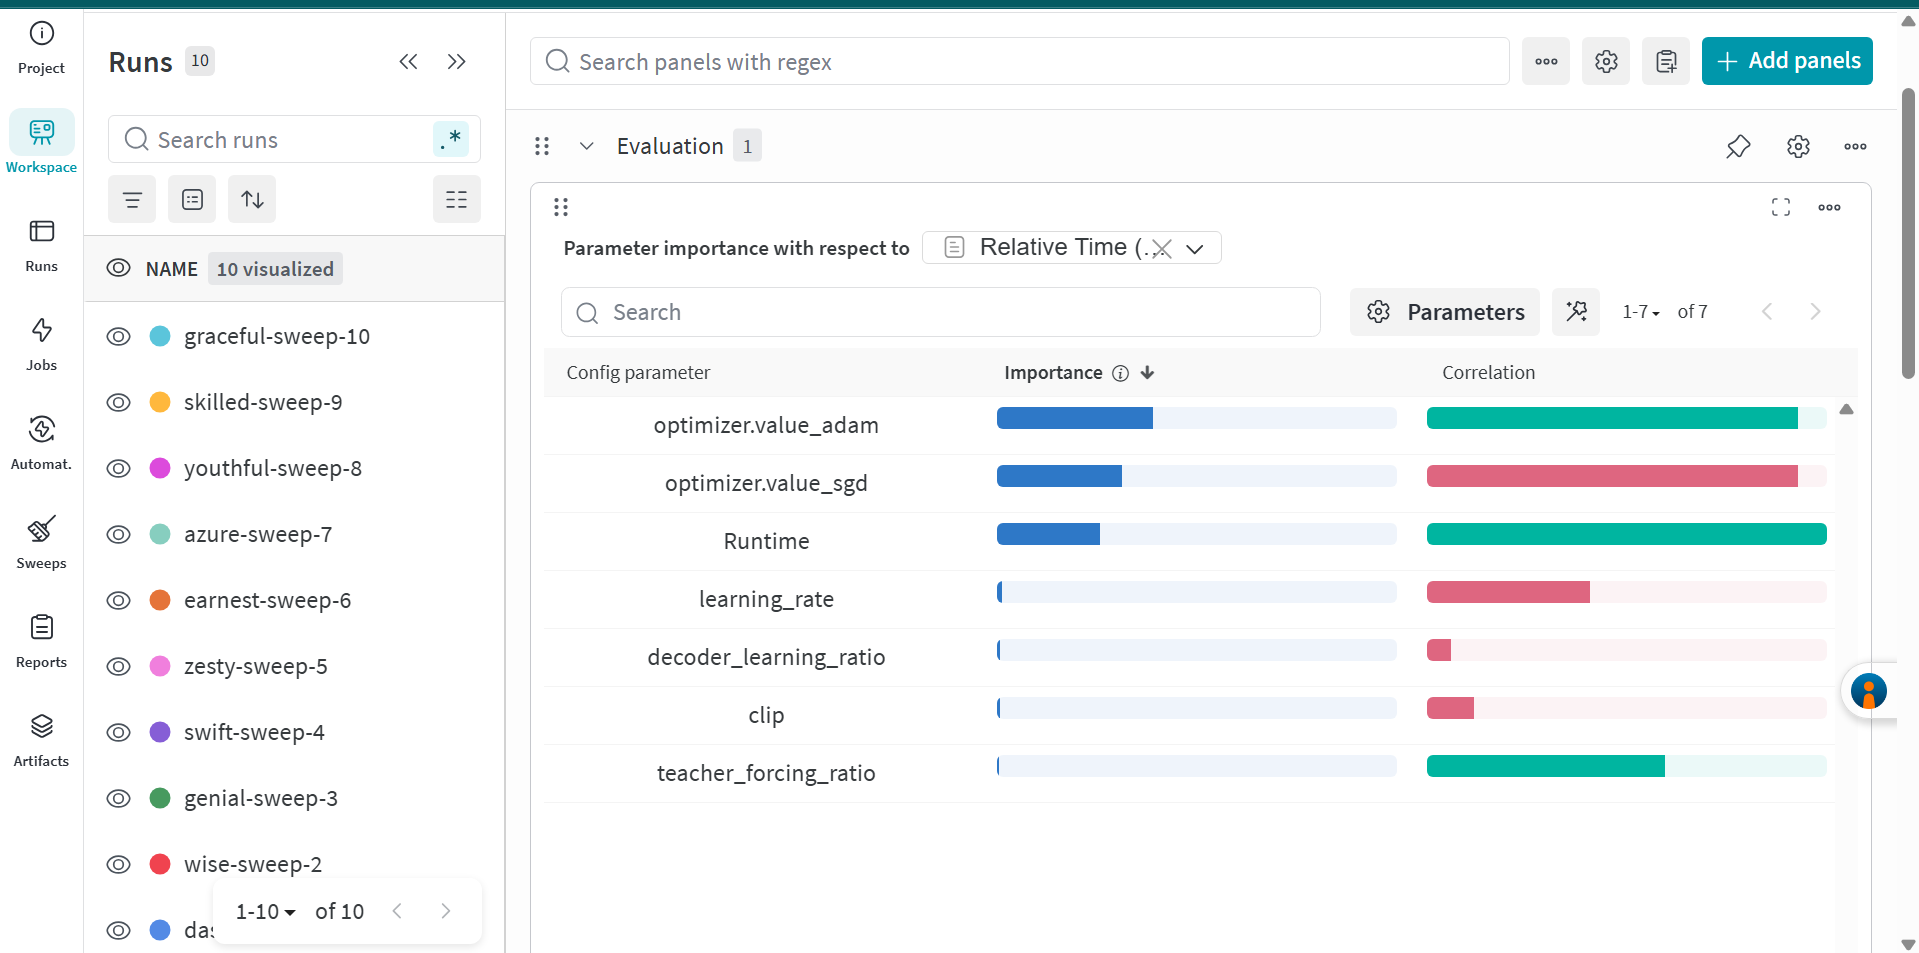

### 5c. Convergence Analysis

Explain, in your own words, **why** the top hyperparameters from 5b affect model convergence. Address each of the following:

- **Learning rate** — how does its magnitude affect gradient update steps and the risk of overshooting minima?
- **Optimizer choice (Adam vs SGD)** — how do adaptive vs. fixed learning rates influence training on sparse/noisy sequence data?
- **Gradient clipping (`clip`)** — why does clipping stabilize RNN training, and what happens when `clip=0` (no clipping) or `clip=100` (very loose)?
- **Teacher forcing ratio** — how does the tradeoff between training with ground-truth vs. predicted tokens affect convergence speed and exposure bias?
- **Decoder learning ratio** — why might the decoder benefit from a different learning rate than the encoder?

*Write your analysis here (aim for 200–400 words).*

Learning rate (0.00025): The learning rate controls the size of each gradient update step. The best value here is relatively small. A large learning rate causes weight updates that overshoot loss minima, making the loss oscillate or diverge entirely. Conversely, a rate that's too small leads to extremely slow convergence and a higher chance of getting trapped in shallow local minima. The value 0.00025 strikes a balance: small enough for stable descent through the noisy loss landscape of sequence-to-sequence training, yet large enough to make meaningful progress within the limited training iterations of the sweep.
Optimizer choice, Adam: Adam maintains per-parameter adaptive learning rates using running estimates of the first and second moments of the gradients. This is critical for sequence data, where gradients can be sparse (many vocabulary tokens are rarely seen) and noisy (batch-to-batch variance is high in dialogue). SGD applies a single fixed step size to all parameters, which struggles in these conditions because rare-token embeddings receive infrequent updates and may need larger steps, while frequent-token parameters may need smaller ones. Adam handles this heterogeneity automatically, leading to faster and more reliable convergence.

Gradient clipping (clip=100): RNNs are prone to exploding gradients due to repeated matrix multiplications through time steps during backpropagation. Clipping rescales the gradient norm when it exceeds a threshold, preventing catastrophically large updates. With clip=0 (no clipping), a single bad batch can produce an enormous gradient that destroys learned weights. With clip=100, clipping is very permissive: it only intervenes in extreme cases, allowing gradients to flow freely under normal conditions while still providing a safety net against the worst explosions. This light-touch approach preserves training signal better than aggressive clipping (e.g., clip=25), which can throttle useful gradient information.

Teacher forcing ratio (1.0): A ratio of 1.0 means the decoder always receives the ground-truth previous token as input during training, rather than its own prediction. This maximizes convergence speed because the decoder never compounds its own errors during a forward pass, so the loss gradients are cleaner. The tradeoff is exposure bias: at inference time, the model must condition on its own (potentially incorrect) predictions, a distribution it never encountered during training. For a short sweep, however, fast convergence dominates, and the model reaches a lower loss within the fixed iteration budget.

Decoder learning ratio (5.0): The encoder maps input sequences into a shared representation space, a task that benefits from cautious, stable updates. The decoder, however, must learn to generate token-by-token output conditioned on attention over encoder states, a harder, more parameter-sensitive task. A higher decoder learning rate (5x the encoder's) lets it adapt faster, compensating for the fact that the decoder's loss surface is more complex and its parameters start further from a good solution than the encoder's.

In [ ]:
# Load the best checkpoint (set path from your best W&B run or save_dir, e.g. save_dir/model_name/corpus_name/2-2_500/500_checkpoint.tar)
best_checkpoint_path = None  # e.g. os.path.join(save_dir, "cb_model", corpus_name, "2-2_500", "500_checkpoint.tar")
if best_checkpoint_path and os.path.exists(best_checkpoint_path):
    checkpoint = torch.load(best_checkpoint_path, map_location=device)
    embedding.load_state_dict(checkpoint["embedding"])
    encoder.load_state_dict(checkpoint["en"])
    decoder.load_state_dict(checkpoint["de"])
    encoder.eval()
    decoder.eval()
    searcher = GreedySearchDecoder(encoder, decoder)
    print("Loaded best checkpoint. Run the cell below to interact.")
else:
    print("Set best_checkpoint_path and re-run, or use existing encoder/decoder from training.")
    searcher = GreedySearchDecoder(encoder, decoder)

Set best_checkpoint_path and re-run, or use existing encoder/decoder from training.


In [ ]:
encoder.eval()
decoder.eval()

searcher = GreedySearchDecoder(encoder, decoder)
evaluateInput(encoder, decoder, searcher, voc)

> Hi bro
Bot: hello . . . . .
> tell me a story
Bot: i m not going to see you .
> this doesn't make sense
Bot: i m not sure . .
> i am sure
Bot: you re not a good man . ?
> i am good, but you are not
Bot: i m not not . ! !
> yes, you are not not
Bot: i m not not . ! !
> quit




### 5d. Chatbot Quality

Load the best checkpoint and interact with the chatbot. Report **at least 5 example exchanges** and briefly comment on the quality of the responses.

```
> Hi bro
Bot: hello . . . . .
> tell me a story
Bot: i m not going to see you .
> this doesn't make sense
Bot: i m not sure . .
> i am sure
Bot: you re not a good man . ?
> i am good, but you are not
Bot: i m not not . ! !
> yes, you are not not
Bot: i m not not . ! !
```

*Replace the template above with your actual exchanges.*